In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import numpy as np
import pandas as pd

In [2]:
wind_data = pd.read_csv('../data/raw/wind_cap_loc_cleaned.csv')
lat = wind_data['Latitude']
long = wind_data['Longitude']

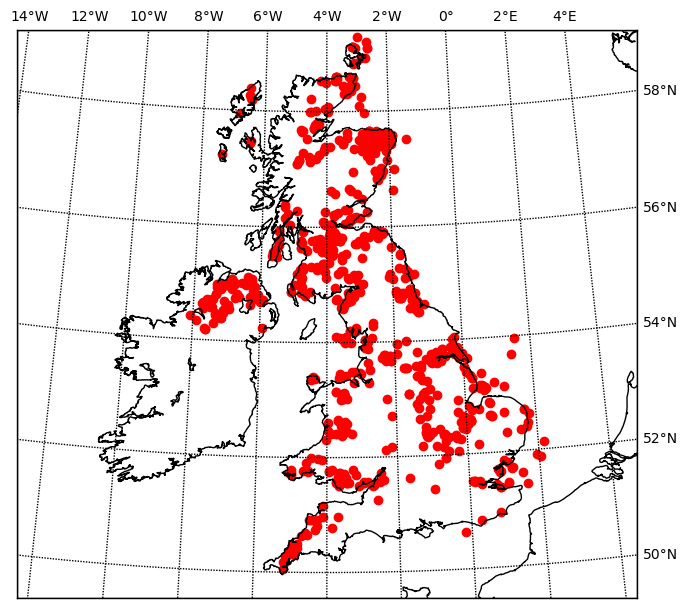

In [ ]:

m = Basemap(width=1200000,height=1100000,projection='lcc',
            resolution='h', area_thresh=100, lat_1=50.,lat_2=51,lat_0=54.5,lon_0=-4.)

plt.figure(figsize=(8, 8))
x, y = m(long, lat)
m.plot(x, y, 'ro')
m.drawcoastlines()
m.drawmapboundary()

parallels = np.arange(50.,61.,2.)
m.drawparallels(parallels,labels=[0,1,0,0],fontsize=10)
meridians = np.arange(-14.,6.,2.)
m.drawmeridians(meridians,labels=[0,0,1,0],fontsize=10)
plt.show()

In [12]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors

In [8]:
lats = wind_data['Latitude'].to_numpy()
lons = wind_data['Longitude'].to_numpy()

cap = wind_data['Installed Capacity (MWelec)'].to_numpy()

In [9]:
def plot_map():
    fig = plt.figure(figsize=(9,10))
    ax = plt.axes(projection=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND)
    ax.add_feature(cfeature.OCEAN)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4)

    ax.set_extent([-9, 3, 49, 61], crs=ccrs.PlateCarree())

    gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.6)
    gl.top_labels = False
    gl.right_labels = False

    return fig, ax

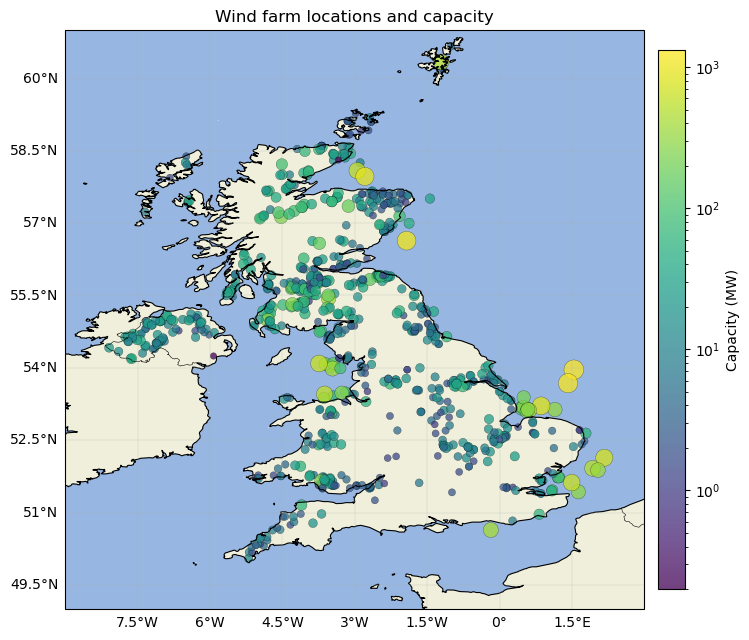

In [ ]:
fig, ax = plot_map()

sizes = 20 + 180 * (np.sqrt(cap) / np.sqrt(np.nanmax(cap) if np.nanmax(cap) > 0 else 1))

norm = mcolors.LogNorm(
    vmin=np.nanmin(cap[cap > 0]),   # log can't handle 0
    vmax=np.nanmax(cap)
)

sc = ax.scatter(
    lons, lats,
    s=sizes,
    c=cap,               
    cmap='viridis',
    norm=norm,
    alpha=0.75,
    edgecolors='k',
    linewidth=0.2,
    transform=ccrs.PlateCarree()
)

cbar = plt.colorbar(sc, ax=ax, orientation='vertical', pad=0.02, shrink=0.7)
cbar.set_label('Capacity (MW)')

ax.set_title('Wind farm locations and capacity')
plt.show()